In [161]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay
import joblib
import warnings
warnings.filterwarnings('ignore')

# Loading the dataset

The first step involves loading the dataset. To load this, Pandas will be used.

In [2]:
df = pd.read_csv("Iris.csv")

Let's check if the data is loaded successfully and what are the features of this data.

In [3]:
df.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [23]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

This shows, that this dataset has four features that give us information about the length and width of sepal and petal. This is a classification problem where we will species the flower category. Let's see how many flowers are there.

In [7]:
df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

There are three categories of thr flowers that we would have to predict which are Iris-setosa, Iris-versicolor and Iris-virginica.

# Data Inspection

Let's inspect the data to checkout the missing values, outliers or mis classification of data.

In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


## Checking for NULL Values

In [19]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

This indicates that there are no null values in this dataset. So, our dataset is already cleaned in terms of the null values.

## Checking for duplicate rows

In [21]:
df[df.duplicated()]

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species


This indicates that our dataset does not have any duplicate rows.

## Checking for Outliers

Let's analyze the outliers from each 4 of the features using **box plot**. Starting analyzing with the **sepal length**.

In [53]:
def boxplotForOutliers(dataframe, column_name, axis_name):
    plt.boxplot(dataframe[column_name], vert=False)
    plt.ylabel('Variable')
    plt.xlabel(axis_name)
    plt.title(f'Box Plot of {axis_name}')
    plt.show() 

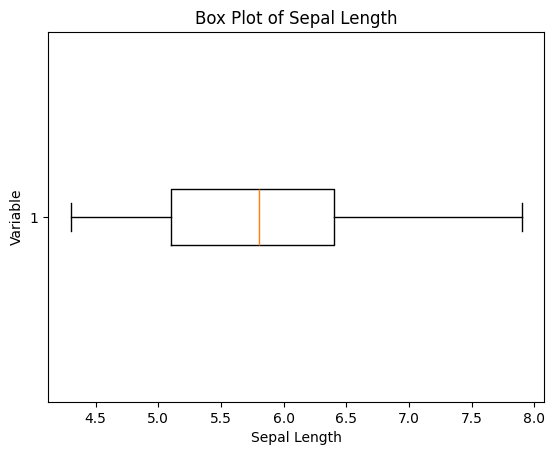

In [54]:
boxplotForOutliers(df, 'SepalLengthCm', 'Sepal Length')

The plot shows that there are no outliers in the Sepal Length. Repeating the process for **Sepal width**, **Petal Length** and **Petal Width**.

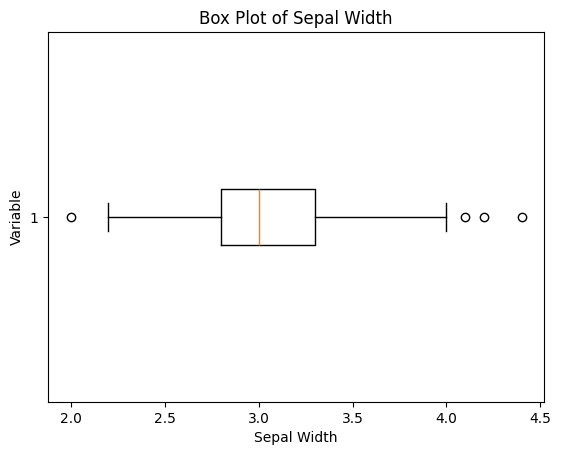

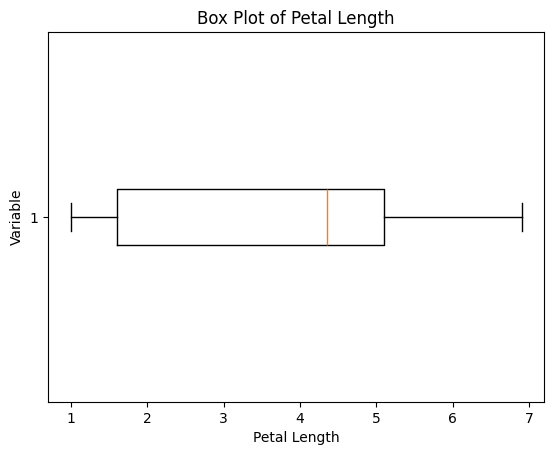

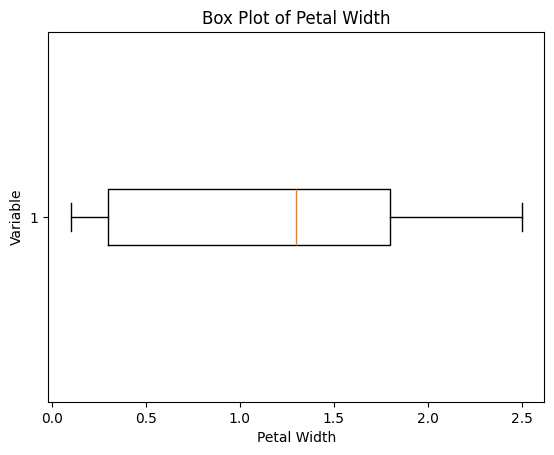

In [55]:
boxplotForOutliers(df, 'SepalWidthCm', 'Sepal Width')
boxplotForOutliers(df, 'PetalLengthCm', 'Petal Length')
boxplotForOutliers(df, 'PetalWidthCm', 'Petal Width')

Only in **Sepal Width**, the outliers are detected.

## Checking for the Classification of data

This step will be used to analyze whether the data is classified in equal ratios between the classes or not.

In [30]:
df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [38]:
Class1Count = len(df[df['Species'].isin(['Iris-setosa'])])
Class2Count = len(df[df['Species'].isin(['Iris-versicolor'])])
Class3Count = len(df[df['Species'].isin(['Iris-virginica'])])

In [40]:
Class1Count, Class2Count, Class3Count

(50, 50, 50)

This shows that our data is perfectly balanced. Let's analyze it with the help of a bar chart.

[]

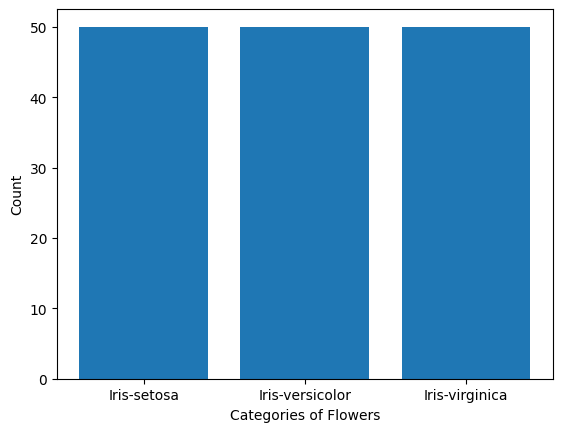

In [68]:
plt.bar(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], [Class1Count, Class2Count, Class3Count])
plt.xlabel("Categories of Flowers")
plt.ylabel("Count")
plt.plot()

# Data Cleaning

From the inspection step, it is clear that most of the part of the data is cleaned. Only the Sepal Width is having some outliers to remove.

## Removing Outliers from Sepal Width

In [63]:
# calculate summary statistics
mean = df['SepalWidthCm'].mean()
std  = df['SepalWidthCm'].std()

# Calculate the lower and upper bounds
lower_bound = mean - std*2
upper_bound = mean + std*2

print('Lower Bound :',lower_bound)
print('Upper Bound :',upper_bound)

# Drop the outliers
df2 = df[(df['SepalWidthCm'] >= lower_bound) & (df['SepalWidthCm'] <= upper_bound)]

Lower Bound : 2.186811377275653
Upper Bound : 3.9211886227243475


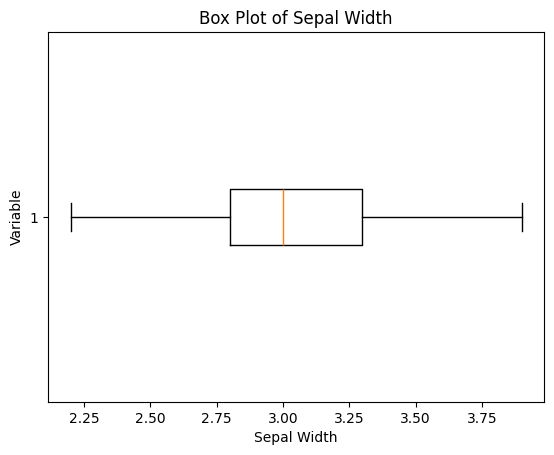

In [64]:
boxplotForOutliers(df2, 'SepalWidthCm', 'Sepal Width')

Now, our outliers from the sepal width columns are also removed. But, the removal must have caused some trouble in data classification. Let's analyze it.

## Data Classification

In [69]:
Class1Count = len(df2[df2['Species'].isin(['Iris-setosa'])])
Class2Count = len(df2[df2['Species'].isin(['Iris-versicolor'])])
Class3Count = len(df2[df2['Species'].isin(['Iris-virginica'])])

In [70]:
Class1Count, Class2Count, Class3Count

(46, 49, 50)

[]

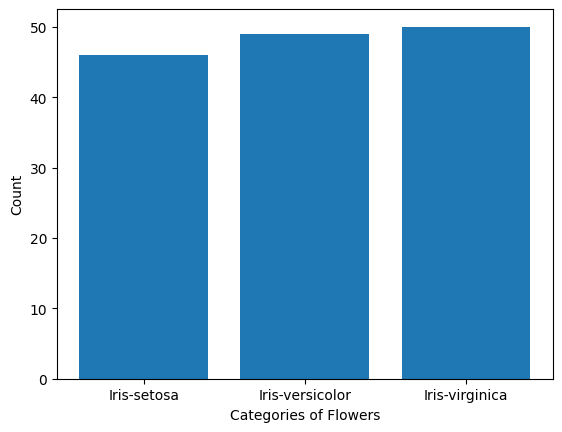

In [71]:
plt.bar(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], [Class1Count, Class2Count, Class3Count])
plt.xlabel("Categories of Flowers")
plt.ylabel("Count")
plt.plot()

This shows a little imbalance in the data after the removal which can be tackled. So, this might be okay. 

Now that our data is cleaned, let's explore various features of this data.

# Feature Engineering

Let's start by checking the datatypes of all the columns and transforming them into the suitable data types.

## Feature Transformation

In [75]:
df2.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

The features are in "float" format. So, they do not need to be altered. However the categorical column "Species" needs to be converted into numerical encoding.

### Converting Categorical Species to Numerical column

In [80]:
mapping = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
df3 = df2.copy()
df3['species_numeric'] = df2['Species'].map(mapping)

## Feature Selection

Let's select the most relevant features to be included in the final dataset and remove the rest. 

In [89]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

ID clearly does not play a part in analyzing the type of the flower. So, here it must be dropped. Also, since we have already converted categorical column to the numerical one, so there is no need to use it now. Let's drop these colums.

In [90]:
df4 = df3.drop(['Id', 'Species'], axis=1)
df4.head(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,species_numeric
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Checking the Co-Relation

In [92]:
df4.corr()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,species_numeric
SepalLengthCm,1.000000,-0.115227,0.885483,0.827138,0.791769
SepalWidthCm,-0.115227,1.000000,-0.382865,-0.315596,-0.386242
PetalLengthCm,0.885483,-0.382865,1.000000,0.961289,0.946972
PetalWidthCm,0.827138,-0.315596,0.961289,1.000000,0.955056
species_numeric,0.791769,-0.386242,0.946972,0.955056,1.000000


<Axes: >

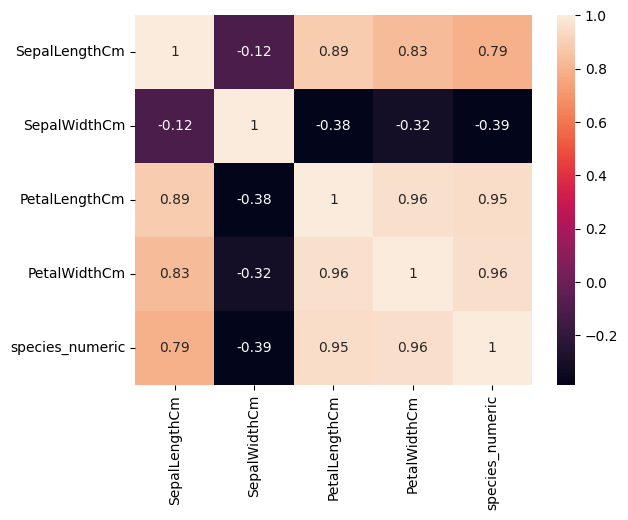

In [94]:
sns.heatmap(df4.corr(), annot=True)

The matrix shows that Petal Length and Petal width are highly co-related and can cause multi-colinearity. Hence, dropping one of these columns, **Petal Width** to remove the multi colinearity.

In [95]:
df5 = df4.drop(['PetalWidthCm'], axis=1)
df5.head(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,species_numeric
0,5.1,3.5,1.4,0
1,4.9,3.0,1.4,0
2,4.7,3.2,1.3,0
3,4.6,3.1,1.5,0
4,5.0,3.6,1.4,0


# Data Splitting

Since, it is a small dataset of only 145 rows, so converting it into train data and test data only. 

In [99]:
X = df5.drop(['species_numeric'], axis = 1)
y = df5['species_numeric']

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [104]:
print(X_train.shape)
print(X_test.shape)

(116, 3)
(29, 3)


## Min Max Scaling

Scaling the data to get it into a similar range to avoid biasing.

In [107]:
scaler = StandardScaler()
Scaler_model = scaler.fit(X_train)
X_train = Scaler_model.transform(X_train)
X_test = Scaler_model.transform(X_test)

# Model Building

Now, comes the most exciting part. Let's build the model to predict the flower type.

## Model Selection

In [109]:
log_reg = LogisticRegression()
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()

# Fit models on the training set
log_reg.fit(X_train, y_train)
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)


DecisionTreeClassifier()

## Model Evaluation

Model: LogisticRegression
Accuracy: 0.896551724137931
Precision: 0.9
Recall: 0.9023569023569024
F1-Score: 0.899749373433584


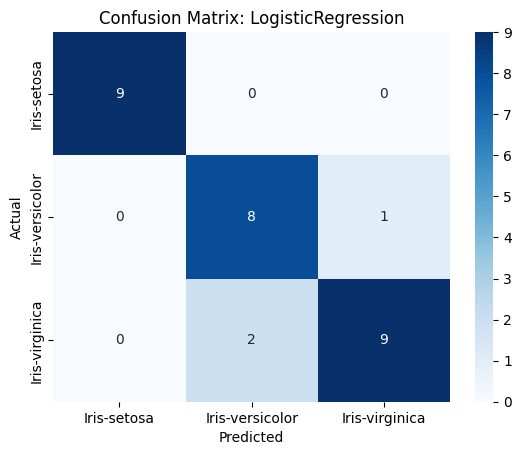

Model: KNeighborsClassifier
Accuracy: 0.8275862068965517
Precision: 0.8472222222222222
Recall: 0.8417508417508417
F1-Score: 0.8329156223893066


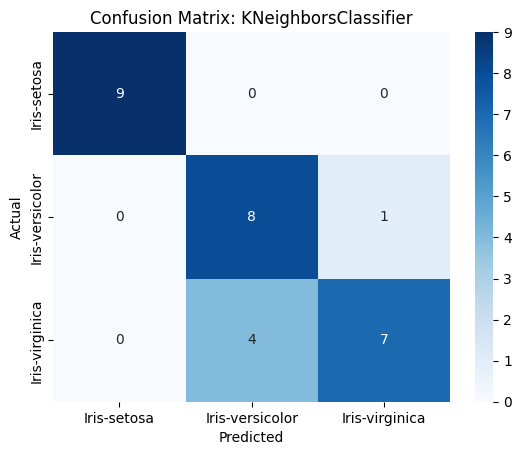

Model: DecisionTreeClassifier
Accuracy: 0.896551724137931
Precision: 0.9
Recall: 0.9023569023569024
F1-Score: 0.899749373433584


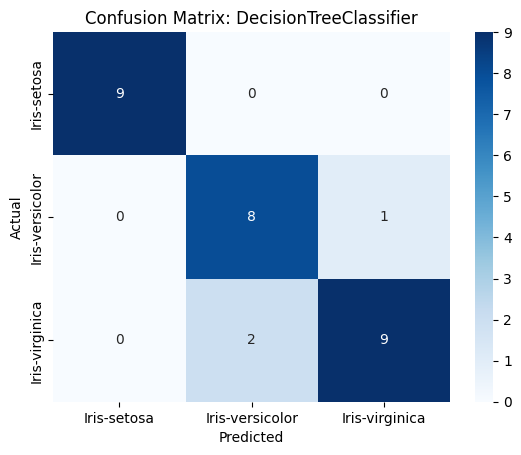

In [117]:
class_names = [i for i in df['Species'].unique()]
class_names
for model in [log_reg, knn, dt]:
    y_pred = model.predict(X_test)
    print(f"Model: {model.__class__.__name__}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
    print(f"Precision: {precision_score(y_test, y_pred, average='macro')}")
    print(f"Recall: {recall_score(y_test, y_pred, average='macro')}")
    print(f"F1-Score: {f1_score(y_test, y_pred, average='macro')}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix: {model.__class__.__name__}')
    plt.show()

The above analysis shows that logistic regression gives almost 89% accuracy, KNeighbour Classifier gives 82% and Decision Tree Classifier also gives 89% of accuracy.

## Plotting ROC Curve

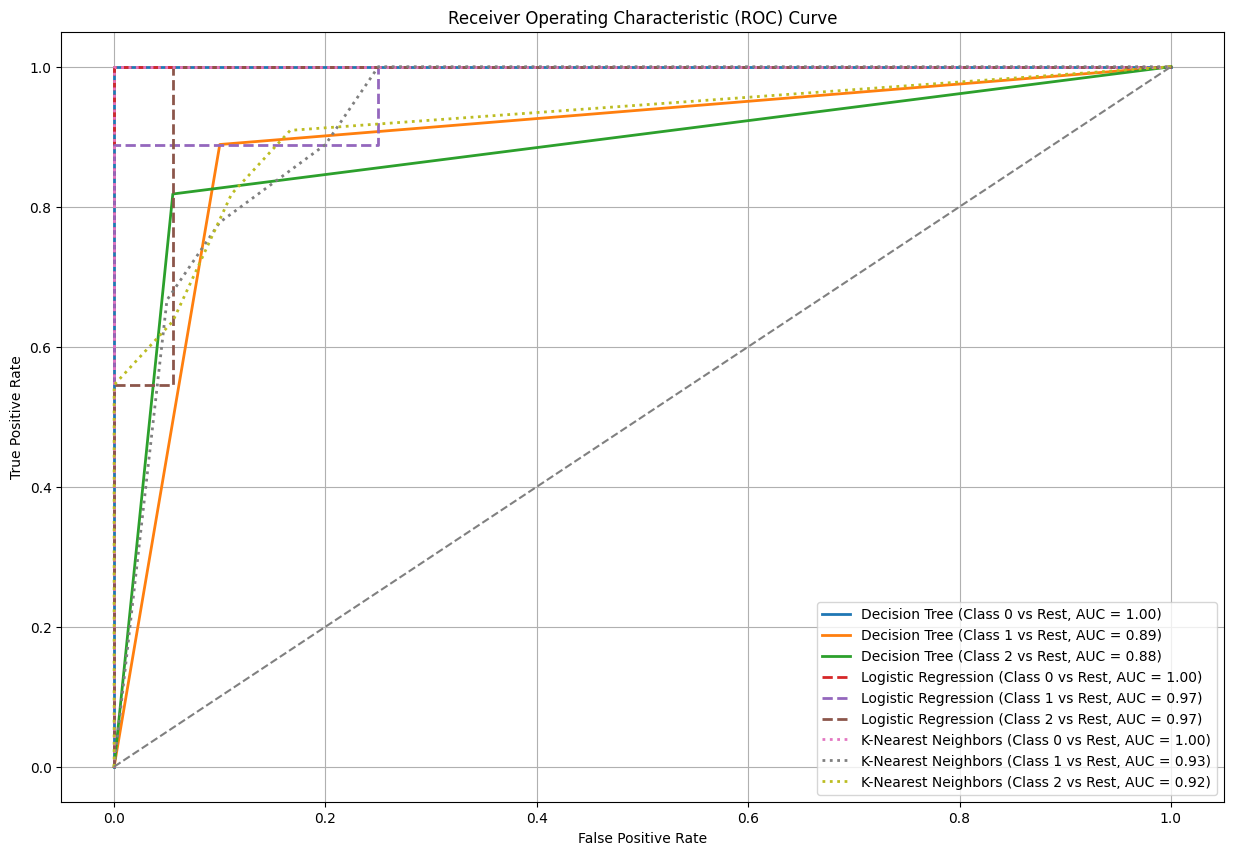

In [133]:
# Binarize the output labels
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # Adjust classes if needed
n_classes = y_test_bin.shape[1]

# Predict probabilities for the test set
y_prob_dt = dt.predict_proba(X_test)
y_prob_lr = log_reg.predict_proba(X_test)
y_prob_knn = knn.predict_proba(X_test)

# Plot ROC curves
plt.figure(figsize=(15, 10))

# ROC curve for Decision Tree
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_dt[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Decision Tree (Class {i} vs Rest, AUC = {roc_auc:.2f})')

# ROC curve for Logistic Regression
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_lr[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, linestyle='--', label=f'Logistic Regression (Class {i} vs Rest, AUC = {roc_auc:.2f})')

# ROC curve for K-Nearest Neighbors
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_knn[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, linestyle=':', label=f'K-Nearest Neighbors (Class {i} vs Rest, AUC = {roc_auc:.2f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Add labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)

# Show plot
plt.show()


Let's analyze the values of AUC. The AUC for class 0 vs. Rest is 1.00 which shows that it is easy to distinguish Setosa than others. AS the score indicates, Logistic Regression has higher score than decision tree which indicates that it may perform well.

So, based on the accuracy **89%** and **AUC-Score**, the best model found is **Logistic Regression**.

# Saving the models

In [135]:
joblib.dump(Scaler_model, 'Scaling_model.pkl')
joblib.dump(log_reg, 'Prediction_model.pkl')

['Prediction_model.pkl']

# Making prediction

In [136]:
Scaler_model = joblib.load('Scaling_model.pkl')
Prediction_model = joblib.load('Prediction_model.pkl')

In [162]:
Numbers_to_class = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}
def prediction():
    Sepal_Length = float(input("Enter the Length of Sepal in cm: "))
    Sepal_Width = float(input("Enter the Width of Sepal in cm: "))
    Petal_Length = float(input("Enter the Length of Petal in cm: "))
    scale = Scaler_model.transform([[Sepal_Length, Sepal_Width, Petal_Length]])
    prediction = Prediction_model.predict(scale)
    print("The Flower is ", Numbers_to_class[prediction[0]])
    return pred

In [163]:
pred = prediction()

Enter the Length of Sepal in cm:  5.1
Enter the Width of Sepal in cm:  3.5
Enter the Length of Petal in cm:  1.4


The Flower is  Iris-setosa
